# Target construction

This notebook runs the target construction module, performs a quick sanity check and realizes EDA over the target.

## Basic Setup

### Imports and Paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_FEAT_PATH = "../data/processed/financial_database_features.parquet"
OUT_MODEL_PATH = "../data/processed/financial_database_model_ready.parquet"

Shape: (27650, 49)


### Load Dataset

In [9]:
df = pd.read_parquet(IN_FEAT_PATH)
df["date"] = pd.to_datetime(df["date"])
print("Shape:", df.shape)

Shape: (27650, 49)


## Target Construction

### Build the Target

The target is built by applying the target construction module to the engineered dataset. This produces a forward-return based label consistent with the modeling horizon.

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.preprocessing.target_construction import TargetConfig, construct_target, make_model_ready

cfg = TargetConfig(
    bot_q=0.30,
    top_q=0.70,
    min_points_cs=5,
)

df_t = construct_target(df, cfg)
df_model = make_model_ready(df_t, cfg)

print("With target:", df_t.shape)
print("Model-ready:", df_model.shape)


With target: (27650, 53)
Model-ready: (27020, 53)


## Exploratory Data Analysis

This section continues with a compact EDA of the model-ready dataset, focusing on target behavior, forward returns, and signal diagnostics.

### Sanity Check

#### NaN ratios

Check the proportion of missing targets. NaNs are expected near the dataset tail because forward returns cannot be computed beyond the available date range.

In [14]:
print("Percentage of missing target values:", df_t["target"].isna().mean() * 100)
print("First date with missing target values:", df_t[df_t["target"].isna()]["date"].min())

Percentage of missing target values: 2.278481012658228
First date with missing target values: 2025-10-01 00:00:00


#### Overall Class Balance

Inspect the global target distribution to understand class balance

In [16]:
df_t["target"].value_counts(normalize=True).sort_index()

target
-1.0    0.3
 0.0    0.4
 1.0    0.3
Name: proportion, dtype: float64

#### Class Balance Over Time

Check how the target mix evolves by year to detect temporal drift.

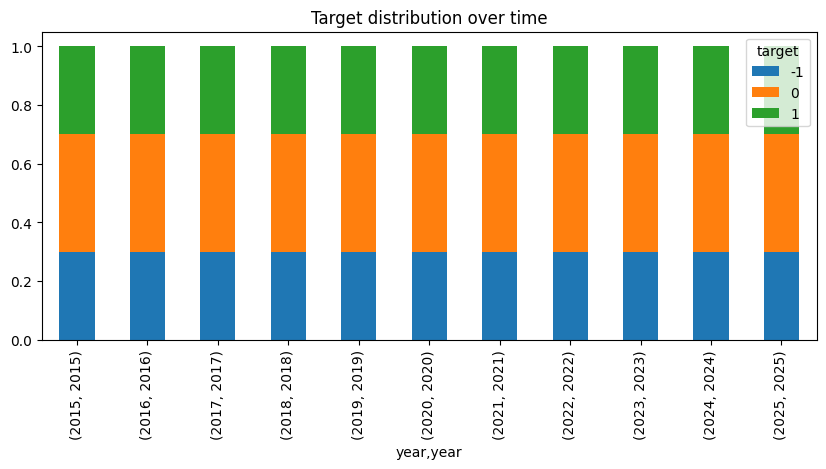

In [ ]:
(
    df_t
    .assign(year=df_t["date"].dt.year)
    .groupby(["year", "target"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack()
    .plot(kind="bar", stacked=True, figsize=(10,4))
)
plt.title("Target distribution over time")
plt.show()


#### Forward return separation by class

Validate coherence by confirming that higher target classes correspond to higher forward returns on average.

<Figure size 640x480 with 0 Axes>

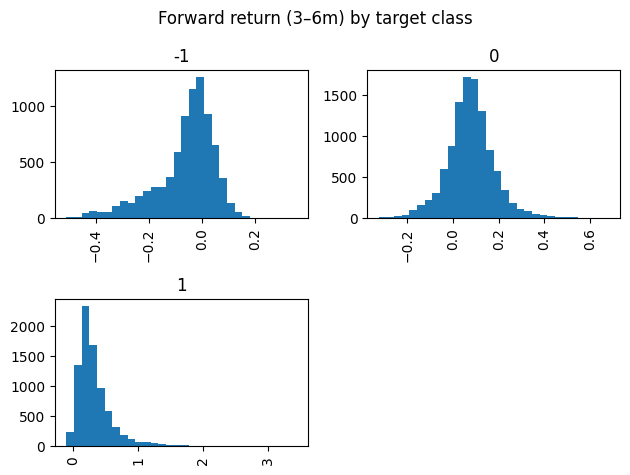

,count,mean,std,min,10%,50%,90%,max
target,,,,,,,,
-1,8106.0,-0.060872,0.112634,-0.511265,-0.225328,-0.035077,0.054070,0.354357
0,10808.0,0.077942,0.105705,-0.324468,-0.042247,0.075409,0.200020,0.680031
1,8106.0,0.330909,0.291410,-0.104325,0.083479,0.259230,0.645452,3.430250


In [15]:
tmp = df_model.copy()

plt.figure()
tmp["fwd_ret_3_6m"].hist(by=tmp["target"], bins=30, grid=False)
plt.suptitle("Forward return (3–6m) by target class")
plt.tight_layout()
plt.show()

tmp.groupby("target")["fwd_ret_3_6m"].describe(percentiles=[.1, .5, .9])


### Information Coefficient Utility

Define a helper to compute per-date Spearman IC between a feature and a forward return.

In [22]:
def compute_ic(df, feature, ret_col):
    ic = (
        df
        .groupby("date")
        .apply(lambda x: x[feature].corr(x[ret_col], method="spearman"), include_groups=False)
    )
    return ic

#### Example IC: ROE vs Forward Returns

Compute the IC distribution for a representative fundamental feature.

In [24]:
import scipy
ic_roe = compute_ic(df_t, "roe", "fwd_ret_3_6m")

print("Mean IC (ROE):", ic_roe.mean())
print("Standatd deviation IC (ROE):", ic_roe.std())

Mean IC (ROE): 0.028791243299015307
Standatd deviation IC (ROE): 0.34907715974586717


#### Rolling IC Stability
Inspect the rolling mean IC to evaluate temporal stability of the signal.

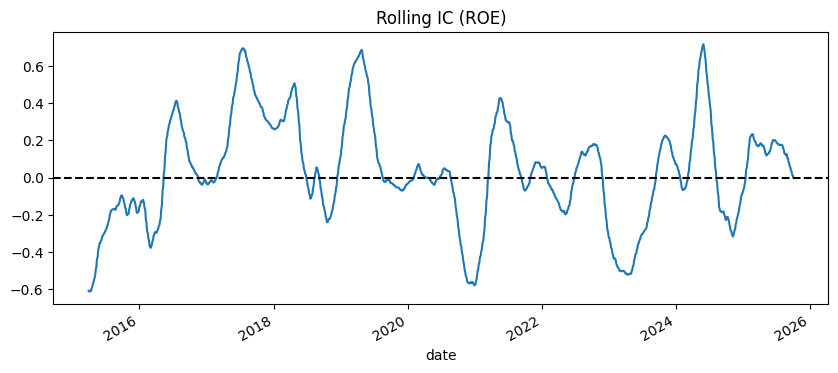

In [19]:
ic_roe.rolling(60).mean().plot(figsize=(10,4))
plt.axhline(0, color="black", linestyle="--")
plt.title("Rolling IC (ROE)")
plt.show()

### Macro Interaction

#### Forward Returns by Macro Regime and Target

Compare average forward returns across macro regimes to validate regime effects.

/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_42174/594733292.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["macro_regime", "target"])


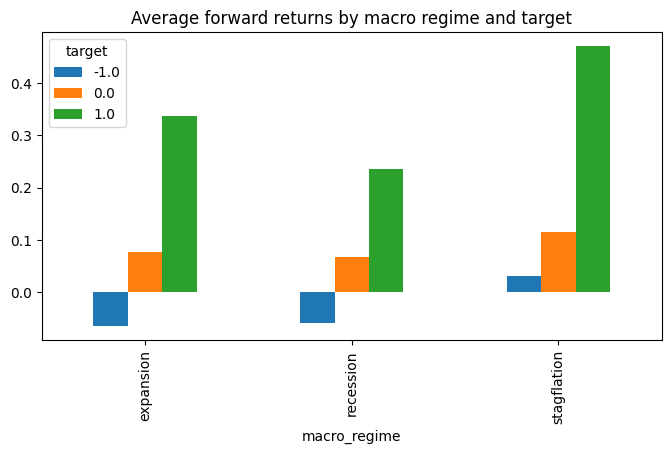

In [25]:
(
    df_t
    .groupby(["macro_regime", "target"])
    ["fwd_ret_3_6m"]
    .mean()
    .unstack()
    .plot(kind="bar", figsize=(8,4))
)
plt.title("Average forward returns by macro regime and target")
plt.show()


### Cross-Sectional Robustness

#### Per-Ticker Correlation Check

Inspect the distribution of per-ticker correlations to ensure the signal is not driven by a single name.

In [26]:
(
    df_t
    .groupby("ticker")
    .apply(lambda x: x["roe"].corr(x["fwd_ret_3_6m"], method="spearman"))
    .sort_values()
)


/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_42174/3652313200.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["roe"].corr(x["fwd_ret_3_6m"], method="spearman"))


ticker
AMZN    -0.361240
NVDA    -0.335617
META    -0.200360
KO      -0.101005
GOOGL   -0.086634
TSLA    -0.084238
MSFT    -0.016300
AAPL     0.002643
JNJ      0.020891
XOM      0.123411
dtype: float64

## Save new dataset

In [ ]:
df_model.to_parquet(OUT_MODEL_PATH, index=False)
print("Saved:", OUT_MODEL_PATH)